In [26]:
!hostname

n103.clstr


In [27]:
import pandas as pd 
import requests
import io
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray as xr
import geopandas as gpd
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [28]:
winter_months = [11, 12, 1, 2, 3]

RICK THOMAN
-

In [29]:
#Rick thoman data 
#https://docs.google.com/spreadsheets/d/1MUeq6N2F8OGBeYOa226iCbaVQBOxj01ibf5IwYqt5nI/edit?gid=0#gid=0
url = "https://docs.google.com/spreadsheets/d/1MUeq6N2F8OGBeYOa226iCbaVQBOxj01ibf5IwYqt5nI/export?format=csv&id=1MUeq6N2F8OGBeYOa226iCbaVQBOxj01ibf5IwYqt5nI&gid=0"
rick_df = pd.read_csv(url)

rick_df['Year'] = pd.to_numeric(rick_df['Year'], errors='coerce')
rick_df['Month'] = pd.to_numeric(rick_df['Month'], errors='coerce')
rick_df['Rain Precip Amount (mm)'] = pd.to_numeric(rick_df['Rain Precip Amount (mm)'],errors='coerce')

rick_season_df = rick_df.loc[rick_df['Month'].isin([11, 12, 1, 2, 3])].copy()
season_start = rick_season_df['Year'].where(~rick_season_df['Month'].isin([1, 2, 3]),rick_season_df['Year'] - 1)
season_end = season_start + 1

rick_season_df['season'] = (season_start.astype(int).astype(str)+ '-'+ season_end.astype(int).astype(str))
rick_season_df['season_sum_rain_mm'] = (rick_season_df.groupby('season')['Rain Precip Amount (mm)'].transform('sum'))

rick_monthly = rick_season_df.groupby('Month')['Rain Precip Amount (mm)'].sum(numeric_only=True)
rick_monthly=rick_monthly.reindex(winter_months).values #correct order 

In [30]:
print(rick_season_df['Rain Precip Amount (mm)'].quantile(0.5))

2.54


In [31]:
test = rick_season_df[
    (rick_season_df['Rain Precip Amount (mm)'] >= 2.54) &
    (rick_season_df['Year'] > 1950)]
test

,Year,Month,Date,Rain Precip Amount (in),Rain Precip Amount (mm),Snowfall (in),Flag,Info,Winter Rain Events in the Greater Fairbanks Area; Measurable rain November through March,season,season_sum_rain_mm
21,1962,12,24,0.28,7.112,1.8,0.1 inch or greater,"Dec 24, 1962: 0.28 inches precip with 1.8 inch...",NaN,1962-1963,21.590
22,1963,1,19-20,0.52,13.208,T,0.1 inch or greater,"Jan 19-20, 1963: 0.52 inches precip, trace sno...",NaN,1962-1963,21.590
24,1967,12,29-30,0.43,10.922,0.5,0.1 inch or greater,"Dec 29-30, 1967: 0.43 inches precip, 0.5"" snow...",NaN,1967-1968,13.462
25,1967,11,21,0.1,2.540,T,0.1 inch or greater,"Nov 21, 1967: 0.10 inches precip, trace snow",NaN,1967-1968,13.462
26,1967,3,4,0.26,6.604,0.9,signigicant mixed rain and snow,"Mar 04, 1967: 0.26 inches precip, 0.9 inches s...",NaN,1966-1967,6.604
27,1970,12,24,0.22,5.588,0.6,0.1 inch or greater,"Dec 24, 1970: 0.22 inches precip mostly rain; ...",NaN,1970-1971,5.588
30,1979,11,06-11,0.36,9.144,NaN,0.1 inch or greater,"Nov 06-11, 1979: six straight days with measur...",NaN,1979-1980,9.144
35,1989,2,25,0.1,2.540,mixed,signigicant mixed rain and snow,"Feb 25, 1989: Snow mixed with and then changed...",NaN,1988-1989,2.540
37,1993,11,9,0.16,4.064,mixed,signigicant mixed rain and snow,"Nov 09, 1993: 0.16 inches precip, mostly mixed...",NaN,1993-1994,4.064
41,2003,11,02-08,0.44,11.176,NaN,0.1 inch or greater,"Nov 02-08, 2003: 0.44 inches or precip during ...",NaN,2003-2004,11.176


In [32]:
rick_season_df

,Year,Month,Date,Rain Precip Amount (in),Rain Precip Amount (mm),Snowfall (in),Flag,Info,Winter Rain Events in the Greater Fairbanks Area; Measurable rain November through March,season,season_sum_rain_mm
0,1920,2,20,0.16,4.064,0.5,signigicant mixed rain and snow,"Feb 20, 1920: 0.16 inches precip with only 0.5...",NaN,1919-1920,4.064
1,1921,3,06-07,0.34,8.636,T,0.1 inch or greater,"Mar 06-07, 1921: 0.34 inches precip, trace sno...",NaN,1920-1921,8.636
2,1923,2,06-07,0.3,7.620,NaN,0.1 inch or greater,"Feb 06-07, 1923: 0.30 inches of precip, Trace ...",NaN,1922-1923,7.620
3,1926,1,12,0.14,3.556,NaN,0.1 inch or greater,"Jan 12, 1926: 0.14 inches rain, no snow",NaN,1925-1926,3.556
4,1926,12,8,0.03,0.762,NaN,less than 0.10 inches,"Dec 08, 1926: 0.03 inches rain, no snow, high 38F",NaN,1926-1927,0.762
...,...,...,...,...,...,...,...,...,...,...,...
59,2019,11,6,<0.01,NaN,mixed,less than 0.10 inches,"Nov 06, 2019: Temps in 20s Snow, then mixed sn...",NaN,2019-2020,0.000
60,2021,12,26-27,1.5,38.100,8-12,0.1 inch or greater,"Dec 26-27, 2021: Massive storm: 8-12 inches of...",NaN,2021-2022,38.100
61,2022,11,13,0.05,1.270,NaN,less than 0.10 inches,"Nov 13, 2022: Tail end of a chinook with trace...",NaN,2022-2023,1.270
62,2024,11,21,0.01,0.254,NaN,less than 0.10 inches,"Nov 21, 2024: Foggy with low stratus, fog and,...",NaN,2024-2025,3.556


In [33]:
rick_dec_2021=rick_season_df[rick_season_df['Year']==2021]
rick_dec_2021
rick_dec_2021_sum= rick_dec_2021['season_sum_rain_mm'].sum()
rick_dec_2021_sum

38.1

In [34]:
rick_nov_2010=rick_season_df[rick_season_df['Year']==2010]
rick_nov_2010
rick_nov_2010_sum= rick_nov_2010['season_sum_rain_mm'].sum()
rick_nov_2010_sum

24.13

Alaska Shapefiles 
-

In [35]:
shapefile_path = "/center1/DYNDOWN/phutton5/ROS/boundaries/Alaska_Borough_and_Census_Area_Boundaries.shp"
borough_boundaries = gpd.read_file(shapefile_path)
borough_boundaries = borough_boundaries.set_crs(epsg=3338)
borough_boundaries = borough_boundaries.to_crs(epsg=4326)
FNSB_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']
FNSB_geom = FNSB_boundary.geometry.iloc[0] 
FNSB_coords = []
FNSB_coords.extend(list(FNSB_geom.exterior.coords))
FNSB_coords = np.array(FNSB_coords)  
FNSB_coords = pd.DataFrame({
    "lon": FNSB_coords[:, 0],
    "lat": FNSB_coords[:, 1]})

Fairbanks_lat=(64.84)
Fairbanks_lon=(-147.72)

ASOS 
-

In [36]:
website='https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?network=AK_ASOS&station=PAFA&data=p01m&data=wxcodes&data=metar&year1=1950&month1=1&day1=1&year2=2023&month2=3&day2=31&tz=Etc%2FUTC&format=onlycomma&latlon=yes&elev=yes&missing=M&trace=T&direct=no&report_type=3&report_type=4'
#'https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?network=AK_ASOS&station=PAFA&data=tmpc&data=p01m&data=wxcodes&data=snowdepth&year1=1949&month1=10&day1=1&year2=2022&month2=12&day2=23&tz=Etc%2FUTC&format=onlycomma&latlon=yes&elev=no&missing=M&trace=T&direct=no&report_type=3&report_type=4'
#https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?network=AK_ASOS&station=PAFA&data=tmpc&data=p01m&data=wxcodes&data=snowdepth&year1=1950&month1=1&day1=1&year2=2023&month2=12&day2=9&tz=America%2FAnchorage&format=onlycomma&latlon=yes&elev=no&missing=M&trace=T&direct=no&report_type=3&report_type=4'
response = requests.get(website)
if response.status_code == 200:
    data = io.StringIO(response.text)
    df = pd.read_csv(data, comment="#")  
    print(df.head())
else:
    print("Error:", response.status_code)

  station             valid       lon      lat  elevation p01m wxcodes  \
0    PAFA  1950-01-01 00:00 -147.8761  64.8039      138.0    M       M   
1    PAFA  1950-01-01 01:00 -147.8761  64.8039      138.0    M       M   
2    PAFA  1950-01-01 02:00 -147.8761  64.8039      138.0    M       M   
3    PAFA  1950-01-01 03:00 -147.8761  64.8039      138.0    M       M   
4    PAFA  1950-01-01 04:00 -147.8761  64.8039      138.0    M       M   

                                               metar  
0  PAFA 010000Z AUTO 1SM M41/M44 RMK SLP393 T1406...  
1  PAFA 010100Z AUTO 10SM M40/M44 RMK SLP386 T140...  
2  PAFA 010200Z AUTO 10SM M41/M45 RMK SLP379 T141...  
3  PAFA 010300Z AUTO 7SM M41/M44 RMK SLP379 T1406...  
4  PAFA 010400Z AUTO 2SM M41/M44 RMK SLP373 T1406...  


In [37]:
df

,station,valid,lon,lat,elevation,p01m,wxcodes,metar
0,PAFA,1950-01-01 00:00,-147.8761,64.8039,138.0,M,M,PAFA 010000Z AUTO 1SM M41/M44 RMK SLP393 T1406...
1,PAFA,1950-01-01 01:00,-147.8761,64.8039,138.0,M,M,PAFA 010100Z AUTO 10SM M40/M44 RMK SLP386 T140...
2,PAFA,1950-01-01 02:00,-147.8761,64.8039,138.0,M,M,PAFA 010200Z AUTO 10SM M41/M45 RMK SLP379 T141...
3,PAFA,1950-01-01 03:00,-147.8761,64.8039,138.0,M,M,PAFA 010300Z AUTO 7SM M41/M44 RMK SLP379 T1406...
4,PAFA,1950-01-01 04:00,-147.8761,64.8039,138.0,M,M,PAFA 010400Z AUTO 2SM M41/M44 RMK SLP373 T1406...
...,...,...,...,...,...,...,...,...
685662,PAFA,2023-03-30 19:53,-147.8761,64.8039,138.0,0.00,M,PAFA 301953Z 05005KT 10SM BKN050 BKN070 M03/M1...
685663,PAFA,2023-03-30 20:53,-147.8761,64.8039,138.0,0.00,M,PAFA 302053Z 00000KT 10SM SCT050 BKN090 00/M11...
685664,PAFA,2023-03-30 21:53,-147.8761,64.8039,138.0,0.00,M,PAFA 302153Z 00000KT 10SM SCT050 BKN090 01/M11...
685665,PAFA,2023-03-30 22:53,-147.8761,64.8039,138.0,0.00,M,PAFA 302253Z 18003KT 10SM SCT050 BKN090 01/M09...


In [38]:
df['valid'] = pd.to_datetime(df['valid'])
df['month'] = df['valid'].dt.month
df['date'] = df['valid'].dt.date
df['time'] = df['valid'].dt.time
#df['tmpc']
#df = df.drop(columns=['column_name'])
winter_df = df[df['month'].isin([11, 12, 1, 2, 3])] #filter to only keep the ROS months 

winter_df['date'] = pd.to_datetime(winter_df['date'])
year = winter_df['date'].dt.year
month = winter_df['date'].dt.month
season_start = year.where(~month.isin([1, 2, 3]), year - 1)
season_end = season_start + 1
winter_df['season'] = season_start.astype(str) + '-' + season_end.astype(str)

#filter to only when RA is present 
mask = winter_df['wxcodes'].str.contains('RA', na=False)
rain_and_mixed_df = winter_df[mask]
rain_and_mixed_df['p01m'] = rain_and_mixed_df['p01m'].replace('M', np.nan) 
#rain_and_mixed_df['p01m'] = rain_and_mixed_df['p01m'].replace('T', np.nan)
rain_and_mixed_df['p01m'] = rain_and_mixed_df['p01m'].replace('T', 0.1)
rain_and_mixed_df['p01m'] = pd.to_numeric(rain_and_mixed_df['p01m'], errors='coerce')

/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1455946/4063370908.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winter_df['date'] = pd.to_datetime(winter_df['date'])
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1455946/4063370908.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winter_df['season'] = season_start.astype(str) + '-' + season_end.astype(str)
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1455946/4063370908.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

In [39]:
# Group by season and month, then sum the precipitation
monthly_sum = (
    rain_and_mixed_df
    .groupby(['season', 'month'], as_index=False)['p01m']
    .sum()
    .rename(columns={'p01m': 'monthly_precip_mm'})
)

print(monthly_sum)
#percentile_rank = (monthly_sum['monthly_precip_mm'] < 2.54).mean() * 100
#percentile_rank

percentileg0 = monthly_sum.loc[monthly_sum['monthly_precip_mm'] > 0, 'monthly_precip_mm'].quantile(0.5)
print(f"50th percentile of monthly precipitation > 0 mm is {percentileg0:.2f} mm")

percentileg05 = monthly_sum.loc[monthly_sum['monthly_precip_mm'] > 0, 'monthly_precip_mm'].quantile(0.8)
print(f"80th percentile of monthly precipitation  is {percentileg05:.2f} mm")

percentile_90_value = monthly_sum.loc[monthly_sum['monthly_precip_mm'] > 0, 'monthly_precip_mm'].quantile(0.9)
print(f"90th percentile of monthly precipitation is {percentile_90_value:.2f} mm")

        season  month  monthly_precip_mm
0    1951-1952     11               0.00
1    1952-1953     11               0.00
2    1953-1954      2               0.00
3    1954-1955      3               0.00
4    1954-1955     11               0.00
..         ...    ...                ...
97   2020-2021     11               1.06
98   2021-2022     12              37.32
99   2022-2023      3               0.75
100  2022-2023     11               1.20
101  2022-2023     12               0.10

[102 rows x 3 columns]
50th percentile of monthly precipitation > 0 mm is 0.76 mm
80th percentile of monthly precipitation  is 2.85 mm
90th percentile of monthly precipitation is 6.10 mm


In [15]:
dec_df=rain_and_mixed_df[rain_and_mixed_df['month']==12]
dec_2021=dec_df[dec_df['season']=='2021-2022']
dec_2021

nov_df=rain_and_mixed_df[rain_and_mixed_df['month']==11]
nov_2010=nov_df[nov_df['season']=='1979-1980']
nov_2010


,station,valid,lon,lat,elevation,p01m,wxcodes,metar,month,date,time,season
265190,PAFA,1979-11-07 06:00:00,-147.8761,64.8039,138.0,NaN,-FZRA,METAR PAFA 070600Z 06004KT 7SM -FZRA OVC017 00...,11,1979-11-07,06:00:00,1979-1980
265191,PAFA,1979-11-07 07:00:00,-147.8761,64.8039,138.0,0.51,-RA,METAR PAFA 070700Z 05003KT 7SM -RA OVC016 01/M...,11,1979-11-07,07:00:00,1979-1980
265192,PAFA,1979-11-07 08:00:00,-147.8761,64.8039,138.0,0.25,-RA,METAR PAFA 070800Z 02005KT 7SM -RA OVC023 01/M...,11,1979-11-07,08:00:00,1979-1980
265196,PAFA,1979-11-07 11:00:00,-147.8761,64.8039,138.0,NaN,-FZRA,METAR PAFA 071100Z 32004KT 7SM -FZRA SCT013 OV...,11,1979-11-07,11:00:00,1979-1980
265218,PAFA,1979-11-08 09:00:00,-147.8761,64.8039,138.0,NaN,-FZRA,METAR PAFA 080900Z 02003KT 7SM -FZRA OVC026 02...,11,1979-11-08,09:00:00,1979-1980
265219,PAFA,1979-11-08 10:00:00,-147.8761,64.8039,138.0,0.25,-FZRA,METAR PAFA 081000Z 34003KT 7SM -FZRA OVC026 01...,11,1979-11-08,10:00:00,1979-1980
265220,PAFA,1979-11-08 11:00:00,-147.8761,64.8039,138.0,0.76,-RA,METAR PAFA 081100Z 03004KT 7SM -RA OVC026 02/M...,11,1979-11-08,11:00:00,1979-1980
265221,PAFA,1979-11-08 12:00:00,-147.8761,64.8039,138.0,0.76,-RA,METAR PAFA 081200Z 36006KT 7SM -RA BKN029 OVC0...,11,1979-11-08,12:00:00,1979-1980
265222,PAFA,1979-11-08 13:00:00,-147.8761,64.8039,138.0,NaN,-RA,METAR PAFA 081300Z 32004KT 7SM -RA BKN029 OVC0...,11,1979-11-08,13:00:00,1979-1980
265254,PAFA,1979-11-09 16:00:00,-147.8761,64.8039,138.0,NaN,-RA,METAR PAFA 091600Z 21007KT 10SM -RA BKN026 OVC...,11,1979-11-09,16:00:00,1979-1980


In [16]:
zero_count_2010 = (nov_2010["p01m"] == 0).sum()

In [17]:
zero_count_2010

0

In [18]:
#Icemaggeddon December 26-28 2021
dec_df=rain_and_mixed_df[rain_and_mixed_df['month']==12]
dec_2021=dec_df[dec_df['season']=='2021-2022']

dec_2021=dec_2021.drop(dec_2021[dec_2021['valid']==pd.Timestamp('2021-12-19 13:48:00')].index)
dec_2021=dec_2021.drop(dec_2021[dec_2021['valid']==pd.Timestamp('2021-12-19 13:53:00')].index)
dec_2021=dec_2021.drop(dec_2021[dec_2021['valid']==pd.Timestamp('2021-12-28 18:21:00')].index)
dec_2021=dec_2021.drop(dec_2021[dec_2021['valid']==pd.Timestamp('2021-12-29 09:53:00')].index)
dec_2021=dec_2021.drop(dec_2021[dec_2021['valid']==pd.Timestamp('2021-12-29 10:00:00')].index)

asos_precip_sum_dec_2021=dec_2021['p01m'].sum()
asos_precip_sum_dec_2021

36.92

In [19]:
# Nov2010  Nov 22-24, 2010:
nov_df=rain_and_mixed_df[rain_and_mixed_df['month']==11]
nov_2010=nov_df[nov_df['season']=='2010-2011']
nov_2010

nov_2010=nov_2010.drop(nov_2010[nov_2010['date']==pd.Timestamp('2010-11-20')].index)
asos_precip_sum_nov_2010=nov_2010['p01m'].sum()
asos_precip_sum_nov_2010
nov_2010

,station,valid,lon,lat,elevation,p01m,wxcodes,metar,month,date,time,season
565617,PAFA,2010-11-22 14:17:00,-147.8761,64.8039,138.0,0.10,-FZRA,PAFA 221417Z 00000KT 9SM -FZRA OVC060 M03/M04 ...,11,2010-11-22,14:17:00,2010-2011
565618,PAFA,2010-11-22 14:53:00,-147.8761,64.8039,138.0,0.25,-FZRA,PAFA 221453Z 00000KT 9SM -FZRA OVC055 M02/M02 ...,11,2010-11-22,14:53:00,2010-2011
565619,PAFA,2010-11-22 15:53:00,-147.8761,64.8039,138.0,0.76,-FZRA,PAFA 221553Z 00000KT 9SM -FZRA OVC060 00/M01 A...,11,2010-11-22,15:53:00,2010-2011
565620,PAFA,2010-11-22 16:53:00,-147.8761,64.8039,138.0,0.76,-FZRA,PAFA 221653Z 00000KT 8SM -FZRA BKN038 OVC050 0...,11,2010-11-22,16:53:00,2010-2011
565621,PAFA,2010-11-22 17:53:00,-147.8761,64.8039,138.0,1.27,-FZRA,PAFA 221753Z 00000KT 7SM -FZRA SCT012 BKN038 O...,11,2010-11-22,17:53:00,2010-2011
...,...,...,...,...,...,...,...,...,...,...,...,...
565679,PAFA,2010-11-24 10:53:00,-147.8761,64.8039,138.0,0.76,-RA BR,PAFA 241053Z 00000KT 4SM -RA BR BKN008 OVC036 ...,11,2010-11-24,10:53:00,2010-2011
565680,PAFA,2010-11-24 11:53:00,-147.8761,64.8039,138.0,1.52,-RA BR,PAFA 241153Z 00000KT 2SM -RA BR SCT006 OVC036 ...,11,2010-11-24,11:53:00,2010-2011
565681,PAFA,2010-11-24 12:18:00,-147.8761,64.8039,138.0,0.10,-RA BR,PAFA 241218Z 00000KT 3SM -RA BR SCT006 OVC036 ...,11,2010-11-24,12:18:00,2010-2011
565686,PAFA,2010-11-24 16:53:00,-147.8761,64.8039,138.0,0.10,-SNRA BR,PAFA 241653Z 00000KT 5SM -SNRA BR BKN005 OVC05...,11,2010-11-24,16:53:00,2010-2011


To Compare PAFA, DYN and RAW
-


In [20]:
pafa_lat=64.8039
pafa_lon=-147.8761

In [21]:
def getXY(lat, lon, dataarray):
    abslat = np.abs(dataarray.XLAT-lat)
    abslon = np.abs(dataarray.XLONG-lon)
    d = abslon**2 + abslat**2
    flat_index = np.argmin(d.values)
    yloc, xloc = np.unravel_index(flat_index, d.shape)
    return xloc, yloc

In [22]:
regridded_era5_path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_November_2010_nearest_regridded_ERA5_31kmto4km_ROS.nc'
regridded_era5=xr.open_dataset(regridded_era5_path)

nov_2010_regridded_era5=regridded_era5.sel(time=slice("2010-11-22", "2010-11-24 23:59:59"))

#ERA5  4km
nov_2010_era5_4km='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Nov2010_hourly.nc' 
nov_2010_era5_4km = xr.open_dataset(nov_2010_era5_4km)

nov_2010_era5_4km = nov_2010_era5_4km.sel(Time=slice("2010-11-22T00:00:00.000000000", "2010-11-25T01:00:00.000000000"))

nov_2010_era5_4km

lat=nov_2010_era5_4km['XLAT'].values
lon=nov_2010_era5_4km['XLONG'].values


In [23]:
dec_2021_regridded_era5_path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_December_2021_nearest_regridded_ERA5_31kmto4km_ROS.nc'
dec_2021_regridded_era5=xr.open_dataset(dec_2021_regridded_era5_path)

dec_2021_regridded_era5=dec_2021_regridded_era5.sel(time=slice("2021-12-26", "2021-12-27 23:59:59"))

#ERA5  4km
dec_2021_era5_4km='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Dec2021_hourly_4km.nc' 
dec_2021_era5_4km = xr.open_mfdataset(dec_2021_era5_4km,combine="by_coords", parallel=True)

dec_2021_era5_4km = dec_2021_era5_4km.sel(Time=slice("2021-12-26", "2021-12-27 23:59:59"))


lat=dec_2021_era5_4km['XLAT'].values
lon=dec_2021_era5_4km['XLONG'].values

x_idx, y_idx = getXY(pafa_lat, pafa_lon, dec_2021_era5_4km)
nearest_lat = dec_2021_era5_4km.XLAT[y_idx, x_idx]
nearest_lon = dec_2021_era5_4km.XLONG[y_idx, x_idx]

dec2021_cell4km = dec_2021_era5_4km.isel(
    south_north=y_idx,
    west_east=x_idx
)

dec2021_cell_regrid=dec_2021_regridded_era5.isel(
    south_north=y_idx,
    west_east=x_idx
)

In [24]:
nov_1967_era5_4km='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Dec1970_hourly.nc' 
nov_1967_era5_4km = xr.open_mfdataset(nov_1967_era5_4km,combine="by_coords", parallel=True)

nov_1967_cell4km = nov_1967_era5_4km.isel(
    south_north=y_idx,
    west_east=x_idx
)

nov_1967_cell4km = nov_1967_cell4km.sel(Time=slice("1970-12-24", "1970-12-25 00:00:00"))

nov_1967_cell4km_sum=nov_1967_cell4km['RAIN'].sum()
print(nov_1967_cell4km_sum.values.item())

11.603076934814453


In [25]:
ROS_Dec1962_hourly='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Mar2016_hourly.nc' 
ROS_Dec1962_hourly = xr.open_mfdataset(ROS_Dec1962_hourly,combine="by_coords", parallel=True)

nov_1967_cell4km = ROS_Dec1962_hourly.isel(
    south_north=y_idx,
    west_east=x_idx
)
nov_1967_cell4km = nov_1967_cell4km.sel(Time=slice("2016-03-28", "2016-03-30 00:00:00"))

nov_1967_cell4km_sum=nov_1967_cell4km['RAIN'].sum()
print(nov_1967_cell4km_sum.values.item())

5.763210296630859


In [26]:
x_idx, y_idx = getXY(pafa_lat, pafa_lon, nov_2010_era5_4km)
nearest_lat = nov_2010_era5_4km.XLAT[y_idx, x_idx]
nearest_lon = nov_2010_era5_4km.XLONG[y_idx, x_idx]

In [27]:
nov2010_cell4km = nov_2010_era5_4km.isel(
    south_north=y_idx,
    west_east=x_idx
)

nov2010_cell_regrid=nov_2010_regridded_era5.isel(
    south_north=y_idx,
    west_east=x_idx
)

In [28]:
nov2010_cell_regrid_sum=nov2010_cell_regrid['rain_during_ros'].sum()
nov2010_cell4km_sum=nov2010_cell4km['RAIN'].sum()
nov2010_cell4km_sum

<xarray.DataArray 'RAIN' ()> Size: 4B
array(32.576004, dtype=float32)
Coordinates:
    XLAT     float32 4B 64.79
    XLONG    float32 4B -147.9

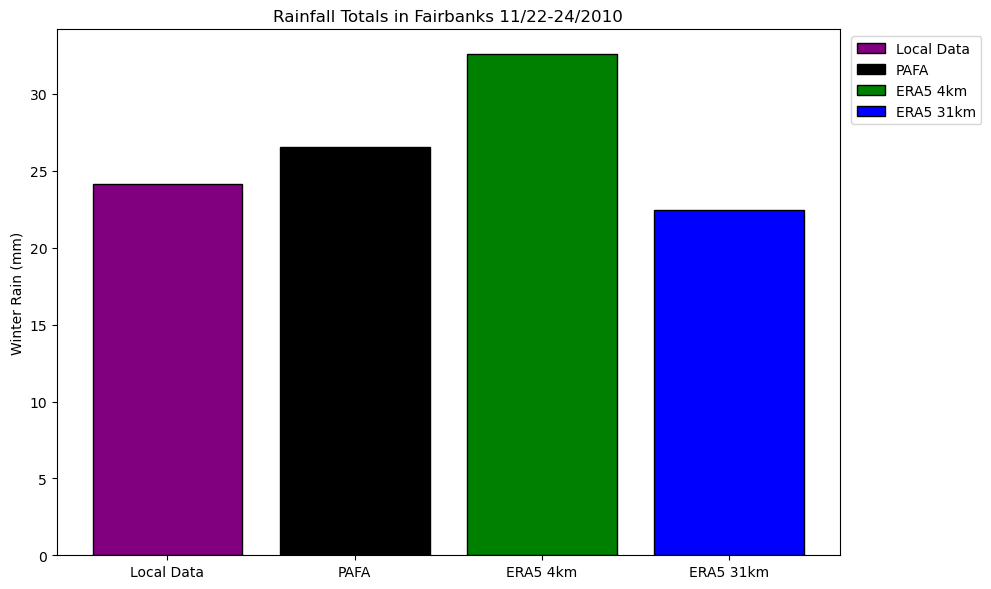

In [29]:
data_labels=['Local Data','PAFA','ERA5 4km','ERA5 31km']
x = np.arange(len(data_labels))
fig, ax = plt.subplots(figsize=(10,6))
data=[rick_nov_2010_sum,asos_precip_sum_nov_2010, nov2010_cell4km_sum, nov2010_cell_regrid_sum]

plt.bar(data_labels, data, color=['purple','black','green','blue'], edgecolor='black', label=data_labels)
ax.set_xticks(x)
ax.set_xticklabels(data_labels)
ax.set_ylabel('Winter Rain (mm)')
ax.set_title('Rainfall Totals in Fairbanks 11/22-24/2010')
ax.legend(loc='upper right', bbox_to_anchor=(1.19, 1))
plt.tight_layout()
plt.show()

In [30]:
#how close to pafa 
asos_precip_sum_nov_2010
nov2010_cell4km_sum
nov2010_cell_regrid_sum

<xarray.DataArray 'rain_during_ros' ()> Size: 8B
array(22.45186864)
Coordinates:
    XLAT     float32 4B ...
    XLONG    float32 4B ...

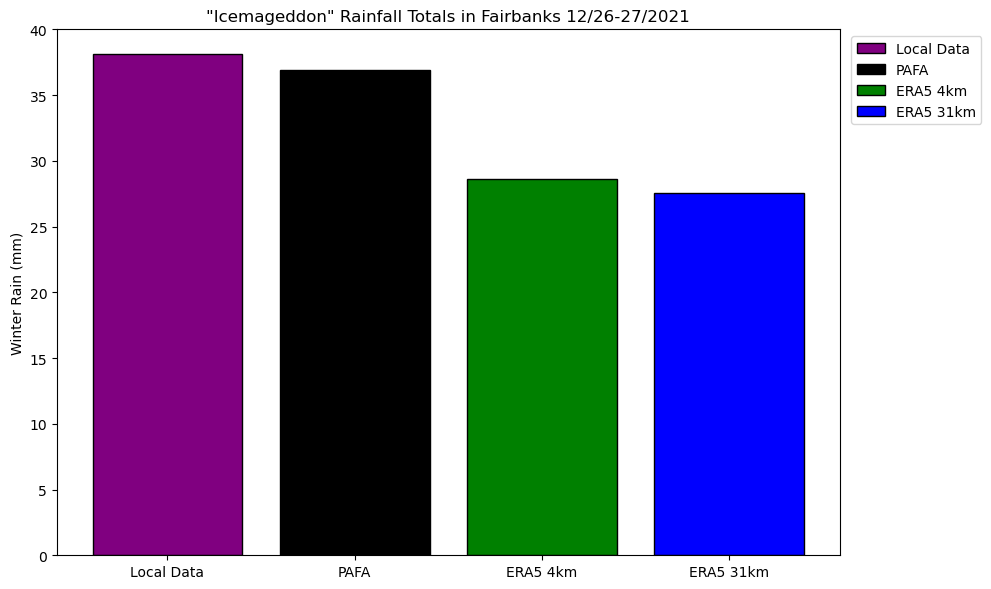

In [31]:
data_labels=['Local Data','PAFA','ERA5 4km','ERA5 31km']
x = np.arange(len(data_labels))
fig, ax = plt.subplots(figsize=(10,6))
data=[rick_dec_2021_sum,asos_precip_sum_dec_2021, dec2021_cell4km['RAIN'].sum(),dec2021_cell_regrid['rain_during_ros'].sum(),]


plt.bar(data_labels, data, color=['purple','black','green','blue'], edgecolor='black', label=data_labels)
ax.set_xticks(x)
ax.set_xticklabels(data_labels)
ax.set_ylabel('Winter Rain (mm)')
ax.set_title('"Icemageddon" Rainfall Totals in Fairbanks 12/26-27/2021')
ax.legend(loc='upper right', bbox_to_anchor=(1.19, 1))
plt.tight_layout()
plt.show()

In [32]:
print(dec2021_cell4km['RAIN'].sum().values.item())

28.629261016845703


In [33]:
#era5 31
regridded_era5_path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ERA5_31kmto4km_nearest_regridded.nc'
regridded_era5=xr.open_dataset(regridded_era5_path)

#ERA5  4km
era5_4km='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Monthly_*.nc'
era5_4km = xr.open_mfdataset(era5_4km,combine="by_coords", parallel=True)


cell_era5_4km = era5_4km.isel(
    south_north=y_idx,
    west_east=x_idx
)

cell_regridded_era5=regridded_era5.isel(
    south_north=y_idx,
    west_east=x_idx
)

In [34]:
march_asos=rain_and_mixed_df[rain_and_mixed_df['month']==3]
march_2016_asos=march_asos[march_asos['season']=='2015-2016']
#march_2016_asos=np.sum(march_2016_asos['p01m'])
march_2016_asos

,station,valid,lon,lat,elevation,p01m,wxcodes,metar,month,date,time,season
616641,PAFA,2016-03-26 07:53:00,-147.8761,64.8039,138.0,0.0,-RA,PAFA 260753Z 00000KT 10SM -RA FEW025 BKN048 OV...,3,2016-03-26,07:53:00,2015-2016
616646,PAFA,2016-03-26 12:53:00,-147.8761,64.8039,138.0,0.0,-RA,PAFA 261253Z 00000KT 10SM -RA SCT027 OVC045 02...,3,2016-03-26,12:53:00,2015-2016
616649,PAFA,2016-03-26 15:53:00,-147.8761,64.8039,138.0,0.0,-RA,PAFA 261553Z 00000KT 10SM -RA FEW034 BKN040 BK...,3,2016-03-26,15:53:00,2015-2016
616724,PAFA,2016-03-29 04:53:00,-147.8761,64.8039,138.0,0.0,-RA,PAFA 290453Z 00000KT 10SM -RA FEW050 BKN070 OV...,3,2016-03-29,04:53:00,2015-2016
616726,PAFA,2016-03-29 06:53:00,-147.8761,64.8039,138.0,0.0,-RA,PAFA 290653Z 00000KT 10SM -RA SCT040 BKN060 OV...,3,2016-03-29,06:53:00,2015-2016
616727,PAFA,2016-03-29 07:53:00,-147.8761,64.8039,138.0,0.0,-RA,PAFA 290753Z 31004KT 8SM -RA SCT025 BKN030 OVC...,3,2016-03-29,07:53:00,2015-2016
616728,PAFA,2016-03-29 08:53:00,-147.8761,64.8039,138.0,0.0,-RA,PAFA 290853Z 04005KT 9SM -RA SCT022 BKN030 OVC...,3,2016-03-29,08:53:00,2015-2016
616729,PAFA,2016-03-29 09:53:00,-147.8761,64.8039,138.0,0.0,-RA,PAFA 290953Z 34004KT 8SM -RA BKN015 OVC030 02/...,3,2016-03-29,09:53:00,2015-2016
616730,PAFA,2016-03-29 10:53:00,-147.8761,64.8039,138.0,0.0,-RA BR,PAFA 291053Z 30003KT 6SM -RA BR SCT015 OVC030 ...,3,2016-03-29,10:53:00,2015-2016
616731,PAFA,2016-03-29 11:53:00,-147.8761,64.8039,138.0,0.0,-RA BR,PAFA 291153Z 00000KT 6SM -RA BR SCT015 OVC030 ...,3,2016-03-29,11:53:00,2015-2016


In [35]:
def selectdata(monthinput, seasoninput):
    # ASOS filter
    asos = rain_and_mixed_df[rain_and_mixed_df['month'] == monthinput]
    asos = asos[asos['season'] == seasoninput]
    asos_sum = np.sum(asos['p01m'])
    
    asos_sum_zeros = (asos["p01m"] == 0).sum()
    
    # ERA5 4km
    era5_4km = cell_era5_4km['rain_sum'].sel(month=monthinput).sel(season=seasoninput)
    
    # ERA5 regridded
    era5_regrid = cell_regridded_era5['rain_sum'].sel(month=monthinput).sel(season=seasoninput)
    
    # Rick dataset
    rick = np.sum(rick_season_df[(rick_season_df['Month'] == monthinput) & 
                                  (rick_season_df['season'] == seasoninput)]['Rain Precip Amount (mm)'])
    
    return asos_sum, era5_4km, era5_regrid, rick,asos_sum_zeros

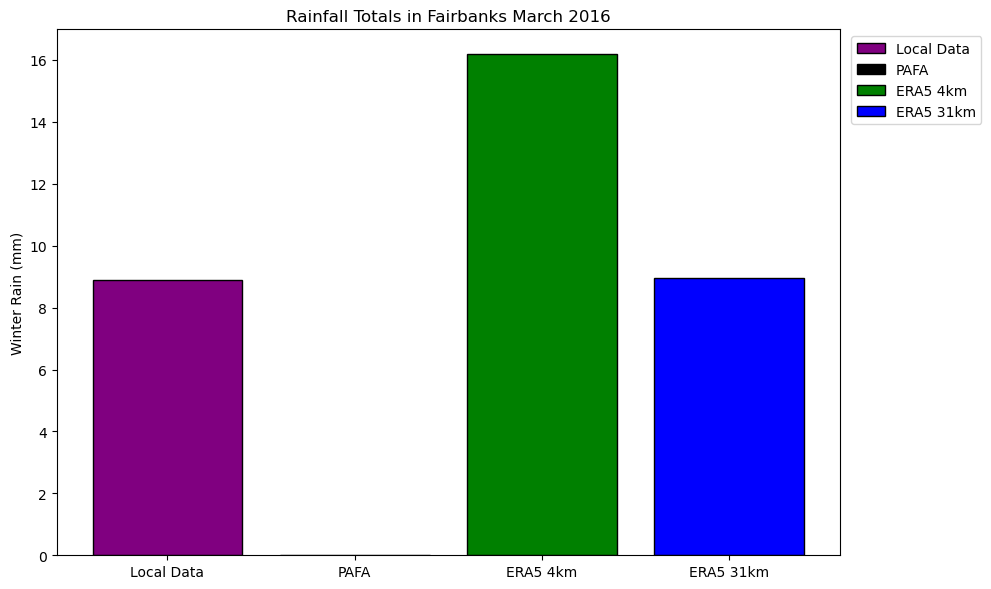

In [36]:
asos_sum, era5_4km, era5_regrid, rick ,asos_sum_zeros= selectdata(3, '2015-2016')

data_labels=['Local Data','PAFA','ERA5 4km','ERA5 31km']
x = np.arange(len(data_labels))
fig, ax = plt.subplots(figsize=(10,6))
data=[rick,asos_sum , era5_4km,era5_regrid]

plt.bar(data_labels, data, color=['purple','black','green','blue'], edgecolor='black', label=data_labels)
ax.set_xticks(x)
ax.set_xticklabels(data_labels)
ax.set_ylabel('Winter Rain (mm)')
ax.set_title('Rainfall Totals in Fairbanks March 2016')
ax.legend(loc='upper right', bbox_to_anchor=(1.19, 1))
plt.tight_layout()
plt.show()

In [37]:
asos_sum_zeros

27

In [38]:
def selectdata(monthinput, seasoninput):

    # ASOS filter
    asos = rain_and_mixed_df[rain_and_mixed_df['month'] == monthinput]
    asos = asos[asos['season'] == seasoninput]
    asos_sum = np.sum(asos['p01m'])
    asos_sum_zeros = (asos["p01m"] == 0).sum()
    
    # ERA5 4km
    era5_4km = cell_era5_4km['rain_sum'].sel(month=monthinput).sel(season=seasoninput)

    # ERA5 regridded
    era5_regrid = cell_regridded_era5['rain_sum'].sel(month=monthinput).sel(season=seasoninput)
    
    # Rick dataset
    rick = np.sum(
        rick_season_df[
            (rick_season_df['Month'] == monthinput) & 
            (rick_season_df['season'] == seasoninput)]['Rain Precip Amount (mm)'] )

    # RMSE calculations
    if asos_sum != 0:
        rmse_31km = np.sqrt(np.mean((era5_regrid.values - asos_sum)**2))
        rmse_4km = np.sqrt(np.mean((era5_4km.values - asos_sum)**2))
    else:
        rmse_31km = np.nan
        rmse_4km = np.nan
    
    return asos_sum, era5_4km, era5_regrid, rick, asos_sum_zeros, rmse_31km, rmse_4km

In [39]:
print(rain_and_mixed_df[rain_and_mixed_df['month'] == 11]['season'].unique())
print(rain_and_mixed_df[rain_and_mixed_df['month'] == 12]['season'].unique())
print(rain_and_mixed_df[rain_and_mixed_df['month'] == 1]['season'].unique())
print(rain_and_mixed_df[rain_and_mixed_df['month'] == 2]['season'].unique())
print(rain_and_mixed_df[rain_and_mixed_df['month'] == 3]['season'].unique())

['1951-1952' '1952-1953' '1954-1955' '1957-1958' '1962-1963' '1965-1966'
 '1967-1968' '1970-1971' '1976-1977' '1979-1980' '1981-1982' '1986-1987'
 '1990-1991' '1993-1994' '1995-1996' '2002-2003' '2003-2004' '2007-2008'
 '2010-2011' '2013-2014' '2015-2016' '2018-2019' '2019-2020' '2020-2021'
 '2022-2023']
['1960-1961' '1961-1962' '1962-1963' '1967-1968' '1970-1971' '1971-1972'
 '1972-1973' '1976-1977' '1984-1985' '1985-1986' '1986-1987' '1992-1993'
 '1998-1999' '1999-2000' '2004-2005' '2009-2010' '2011-2012' '2013-2014'
 '2014-2015' '2016-2017' '2017-2018' '2021-2022' '2022-2023']
['1956-1957' '1960-1961' '1961-1962' '1962-1963' '1975-1976' '1980-1981'
 '1990-1991' '1996-1997' '2000-2001' '2001-2002' '2007-2008' '2008-2009'
 '2012-2013' '2013-2014' '2014-2015' '2015-2016' '2017-2018']
['1953-1954' '1956-1957' '1969-1970' '1975-1976' '1981-1982' '1985-1986'
 '1988-1989' '1990-1991' '2002-2003' '2005-2006' '2010-2011' '2013-2014'
 '2014-2015' '2016-2017' '2018-2019']
['1954-1955' '1957-19

In [40]:
print(rain_and_mixed_df[
    (rain_and_mixed_df['month'] == 2) & 
    (rain_and_mixed_df['season'] == '2014-2015')
])

       station               valid       lon      lat  elevation  p01m  \
606124    PAFA 2015-02-22 03:51:00 -147.8761  64.8039      138.0   0.0   
606125    PAFA 2015-02-22 03:53:00 -147.8761  64.8039      138.0   0.0   
606127    PAFA 2015-02-22 04:53:00 -147.8761  64.8039      138.0   0.0   
606129    PAFA 2015-02-22 05:42:00 -147.8761  64.8039      138.0   0.0   
606130    PAFA 2015-02-22 05:53:00 -147.8761  64.8039      138.0   0.0   
606132    PAFA 2015-02-22 06:38:00 -147.8761  64.8039      138.0   0.0   
606133    PAFA 2015-02-22 06:53:00 -147.8761  64.8039      138.0   0.0   
606134    PAFA 2015-02-22 07:53:00 -147.8761  64.8039      138.0   0.0   
606135    PAFA 2015-02-22 08:53:00 -147.8761  64.8039      138.0   0.0   
606136    PAFA 2015-02-22 09:53:00 -147.8761  64.8039      138.0   0.0   
606137    PAFA 2015-02-22 10:53:00 -147.8761  64.8039      138.0   0.0   
606138    PAFA 2015-02-22 11:53:00 -147.8761  64.8039      138.0   0.0   
606139    PAFA 2015-02-22 12:30:00 -14

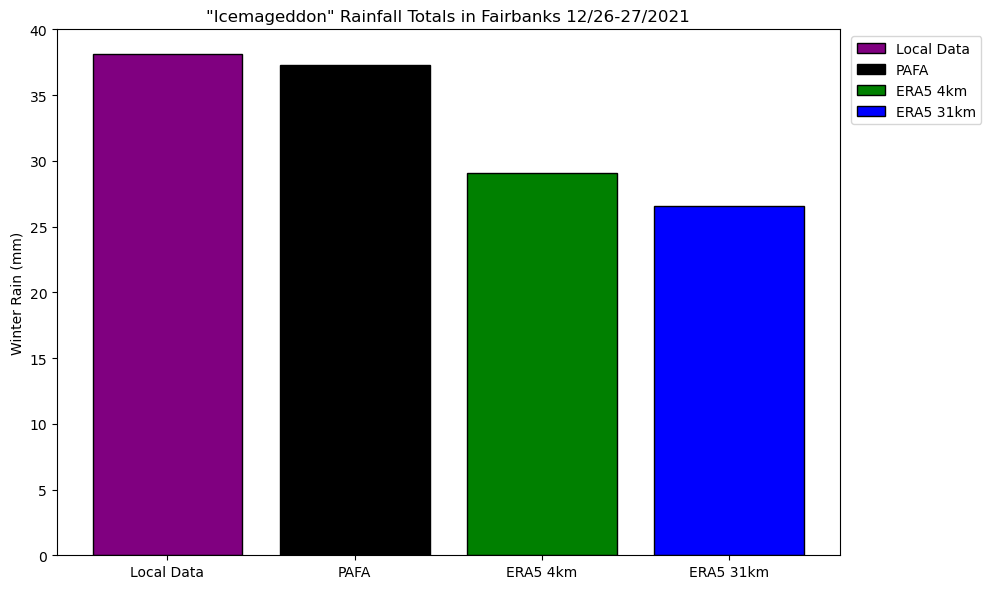

asos sum zeros: 6 RMSE 31km: 10.745508705851833 RMSE 4km: 8.229677505493171
Local (Rick): 38.10 mm
ERA5 4km:  29.09 mm  |  diff: 9.01 mm  |  23.6%
ERA5 31km: 26.57 mm  |  diff: 11.53 mm  |  30.3%
ERA5 4km is closer to local data


In [41]:
asos_sum, era5_4km, era5_regrid, rick , asos_sum_zeros_2_2015, rmse_31km_2_2015, rmse_4km_2_2015 = selectdata(12, '2021-2022')

data_labels=['Local Data','PAFA','ERA5 4km','ERA5 31km']
x = np.arange(len(data_labels))
fig, ax = plt.subplots(figsize=(10,6))
#data=[rick, asos_sum, era5_4km,era5_regrid]
data = [rick, asos_sum, era5_4km.values.item(), era5_regrid.values.item()]

plt.bar(data_labels, data, color=['purple','black','green','blue'], edgecolor='black', label=data_labels)
ax.set_xticks(x)
ax.set_xticklabels(data_labels)
ax.set_ylabel('Winter Rain (mm)')
ax.set_title('"Icemageddon" Rainfall Totals in Fairbanks 12/26-27/2021')
ax.legend(loc='upper right', bbox_to_anchor=(1.19, 1))
plt.tight_layout()
plt.show()

print('asos sum zeros:', asos_sum_zeros_2_2015, 'RMSE 31km:' ,rmse_31km_2_2015, 'RMSE 4km:', rmse_4km_2_2015)

era5_4km_val = era5_4km.values.item()
era5_regrid_val = era5_regrid.values.item()

# Absolute difference from local data
diff_4km = abs(era5_4km_val - rick)
diff_31km = abs(era5_regrid_val - rick)

# Percent difference from local data
pct_4km = (diff_4km / rick) * 100 if rick != 0 else np.nan
pct_31km = (diff_31km / rick) * 100 if rick != 0 else np.nan

print(f"Local (Rick): {rick:.2f} mm")
print(f"ERA5 4km:  {era5_4km_val:.2f} mm  |  diff: {diff_4km:.2f} mm  |  {pct_4km:.1f}%")
print(f"ERA5 31km: {era5_regrid_val:.2f} mm  |  diff: {diff_31km:.2f} mm  |  {pct_31km:.1f}%")
print(f"{'ERA5 4km' if diff_4km < diff_31km else 'ERA5 31km'} is closer to local data")

2/22/2015
-

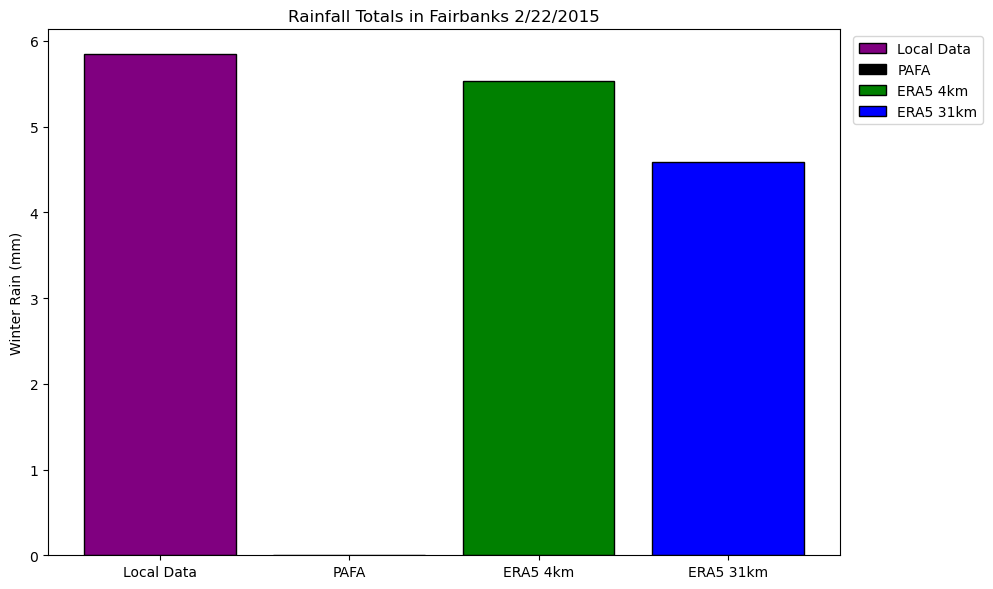

asos sum zeros: 15 RMSE 31km: nan RMSE 4km: nan
Local (Rick): 5.84 mm
ERA5 4km:  5.53 mm  |  diff: 0.31 mm  |  5.4%
ERA5 31km: 4.59 mm  |  diff: 1.25 mm  |  21.4%
ERA5 4km is closer to local data


In [42]:
asos_sum, era5_4km, era5_regrid, rick ,asos_sum_zeros_2_2015, rmse_31km_2_2015, rmse_4km_2_2015 = selectdata(2, '2014-2015')

data_labels=['Local Data','PAFA','ERA5 4km','ERA5 31km']
x = np.arange(len(data_labels))
fig, ax = plt.subplots(figsize=(10,6))
data=[rick,0 , era5_4km,era5_regrid]

plt.bar(data_labels, data, color=['purple','black','green','blue'], edgecolor='black', label=data_labels)
ax.set_xticks(x)
ax.set_xticklabels(data_labels)
ax.set_ylabel('Winter Rain (mm)')
ax.set_title('Rainfall Totals in Fairbanks 2/22/2015')
ax.legend(loc='upper right', bbox_to_anchor=(1.19, 1))
plt.tight_layout()
plt.show()

print('asos sum zeros:', asos_sum_zeros_2_2015, 'RMSE 31km:' ,rmse_31km_2_2015, 'RMSE 4km:', rmse_4km_2_2015)


era5_4km_val = era5_4km.values.item()
era5_regrid_val = era5_regrid.values.item()

# Absolute difference from local data
diff_4km = abs(era5_4km_val - rick)
diff_31km = abs(era5_regrid_val - rick)

# Percent difference from local data
pct_4km = (diff_4km / rick) * 100 if rick != 0 else np.nan
pct_31km = (diff_31km / rick) * 100 if rick != 0 else np.nan

print(f"Local (Rick): {rick:.2f} mm")
print(f"ERA5 4km:  {era5_4km_val:.2f} mm  |  diff: {diff_4km:.2f} mm  |  {pct_4km:.1f}%")
print(f"ERA5 31km: {era5_regrid_val:.2f} mm  |  diff: {diff_31km:.2f} mm  |  {pct_31km:.1f}%")
print(f"{'ERA5 4km' if diff_4km < diff_31km else 'ERA5 31km'} is closer to local data")

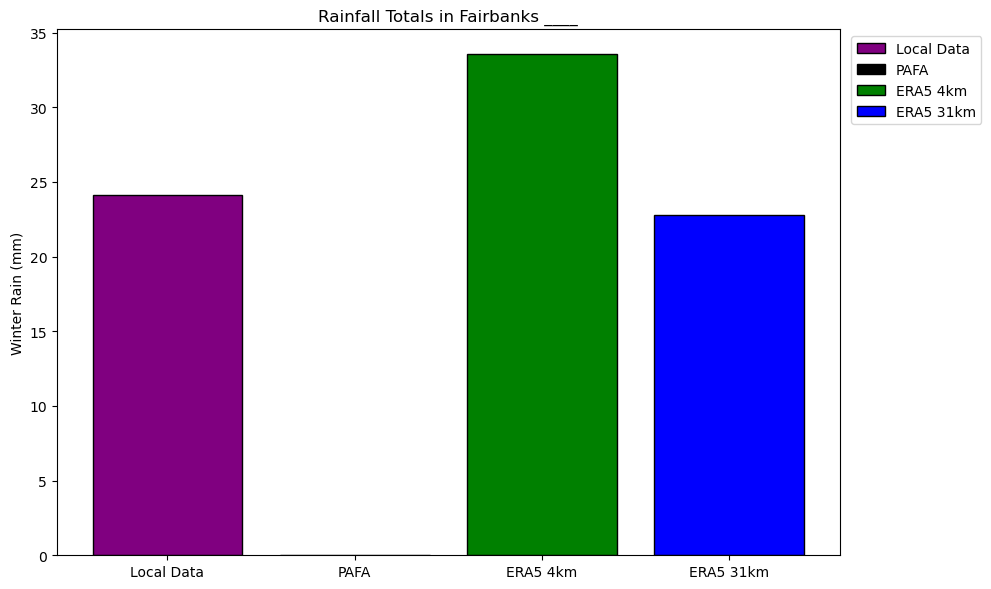

asos sum zeros: 3 RMSE 31km: 4.603470303627137 RMSE 4km: 6.1470924377441385
Local (Rick): 24.13 mm
ERA5 4km:  33.55 mm  |  diff: 9.42 mm  |  39.0%
ERA5 31km: 22.80 mm  |  diff: 1.33 mm  |  5.5%
ERA5 31km is closer to local data


In [43]:
asos_sum, era5_4km, era5_regrid, rick ,asos_sum_zeros_2_2015, rmse_31km_2_2015, rmse_4km_2_2015 = selectdata(11, '2010-2011')

data_labels=['Local Data','PAFA','ERA5 4km','ERA5 31km']
x = np.arange(len(data_labels))
fig, ax = plt.subplots(figsize=(10,6))
data=[rick,0 , era5_4km,era5_regrid]

plt.bar(data_labels, data, color=['purple','black','green','blue'], edgecolor='black', label=data_labels)
ax.set_xticks(x)
ax.set_xticklabels(data_labels)
ax.set_ylabel('Winter Rain (mm)')
ax.set_title('Rainfall Totals in Fairbanks ____')
ax.legend(loc='upper right', bbox_to_anchor=(1.19, 1))
plt.tight_layout()
plt.show()

print('asos sum zeros:', asos_sum_zeros_2_2015, 'RMSE 31km:' ,rmse_31km_2_2015, 'RMSE 4km:', rmse_4km_2_2015)


era5_4km_val = era5_4km.values.item()
era5_regrid_val = era5_regrid.values.item()

# Absolute difference from local data
diff_4km = abs(era5_4km_val - rick)
diff_31km = abs(era5_regrid_val - rick)

# Percent difference from local data
pct_4km = (diff_4km / rick) * 100 if rick != 0 else np.nan
pct_31km = (diff_31km / rick) * 100 if rick != 0 else np.nan

print(f"Local (Rick): {rick:.2f} mm")
print(f"ERA5 4km:  {era5_4km_val:.2f} mm  |  diff: {diff_4km:.2f} mm  |  {pct_4km:.1f}%")
print(f"ERA5 31km: {era5_regrid_val:.2f} mm  |  diff: {diff_31km:.2f} mm  |  {pct_31km:.1f}%")
print(f"{'ERA5 4km' if diff_4km < diff_31km else 'ERA5 31km'} is closer to local data")

In [44]:
# Get unique months in rick dataset
rick_months = rick_season_df['Month'].unique()
print(rick_months)  # e.g. [2, 3, 1, 12, 11]

# Filter by season first, then get unique months for that season
def get_rick_months(seasoninput):
    rick_filtered = rick_season_df[rick_season_df['season'] == seasoninput]
    return rick_filtered['Month'].unique()

# Then use those months to select from other datasets
def selectdata_by_rick_months(seasoninput):
    rick_months = get_rick_months(seasoninput)
    
    results = {}
    for month in rick_months:
        asos = rain_and_mixed_df[rain_and_mixed_df['month'] == month]
        asos = asos[asos['season'] == seasoninput]
        asos_sum = np.sum(asos['p01m'])

        era5_4km = cell_era5_4km['rain_sum'].sel(month=month).sel(season=seasoninput).compute().item()
        era5_regrid = cell_regridded_era5['rain_sum'].sel(month=month).sel(season=seasoninput).compute().item()
        
        rick = np.sum(rick_season_df[(rick_season_df['Month'] == month) &
                                      (rick_season_df['season'] == seasoninput)]['Rain Precip Amount (mm)'])

        results[month] = {
            'asos': asos_sum,
            'era5_4km': era5_4km,
            'era5_regrid': era5_regrid,
            'rick': rick}
    return results

results = selectdata_by_rick_months('2015-2016')

results

[ 2  3  1 12 11]


{3: {'asos': 0.0,
  'era5_4km': 16.179397583007812,
  'era5_regrid': 8.944868307075614,
  'rick': 8.89}}

In [45]:
results = []

for season in rain_and_mixed_df['season'].unique():
    try:
        total_rick = 0
        total_asos = 0
        total_era5_4km = 0
        total_era5_31km = 0

        for month in rain_and_mixed_df['month'].unique():
            asos_sum, era5_4km, era5_regrid, rick, asos_zeros, rmse_31km, rmse_4km = selectdata(month, season)
            total_rick += rick
            total_asos += asos_sum
            total_era5_4km += era5_4km.values.item()
            total_era5_31km += era5_regrid.values.item()

        diff_4km = abs(total_era5_4km - total_rick)
        diff_31km = abs(total_era5_31km - total_rick)

        pct_4km = (diff_4km / total_rick) * 100 if total_rick != 0 else np.nan
        pct_31km = (diff_31km / total_rick) * 100 if total_rick != 0 else np.nan

        closer = 'ERA5 4km' if diff_4km < diff_31km else 'ERA5 31km'

        results.append({
            'season': season,
            'rick': total_rick,
            'asos_sum': total_asos,
            'era5_4km': total_era5_4km,
            'era5_31km': total_era5_31km,
            'diff_4km': diff_4km,
            'diff_31km': diff_31km,
            'pct_4km': pct_4km,
            'pct_31km': pct_31km,
            'closer': closer
        })

        print(f"{season} | Rick: {total_rick:6.2f}mm | "
              f"4km: {total_era5_4km:6.2f}mm ({pct_4km:5.1f}%) | "
              f"31km: {total_era5_31km:6.2f}mm ({pct_31km:5.1f}%) | "
              f"→ {closer} closer")

    except Exception as e:
        print(f"{season} | SKIPPED: {e}")

# Summary
results_df = pd.DataFrame(results)
valid = results_df[results_df['rick'] != 0]

print("\n--- SUMMARY ---")
print(f"ERA5 4km  closer: {(valid['closer'] == 'ERA5 4km').sum()} / {len(valid)} seasons")
print(f"ERA5 31km closer: {(valid['closer'] == 'ERA5 31km').sum()} / {len(valid)} seasons")
print(f"\nMean abs diff - 4km:  {valid['diff_4km'].mean():.2f}mm")
print(f"Mean abs diff - 31km: {valid['diff_31km'].mean():.2f}mm")

1951-1952 | Rick:   0.00mm | 4km:   4.91mm (  nan%) | 31km:   0.66mm (  nan%) | → ERA5 31km closer
1952-1953 | Rick:   0.00mm | 4km:   4.95mm (  nan%) | 31km:   2.43mm (  nan%) | → ERA5 31km closer
1953-1954 | Rick:   0.00mm | 4km:   4.75mm (  nan%) | 31km:   0.35mm (  nan%) | → ERA5 31km closer
1954-1955 | Rick:   0.25mm | 4km:   7.66mm (2915.2%) | 31km:   6.43mm (2430.4%) | → ERA5 31km closer
1956-1957 | Rick:   0.76mm | 4km:  16.85mm (2110.8%) | 31km:   3.02mm (296.0%) | → ERA5 31km closer
1957-1958 | Rick:   0.00mm | 4km:   6.81mm (  nan%) | 31km:   1.80mm (  nan%) | → ERA5 31km closer
1960-1961 | Rick:   1.02mm | 4km:   3.55mm (249.4%) | 31km:   1.04mm (  2.7%) | → ERA5 31km closer
1961-1962 | Rick:   0.00mm | 4km:  18.47mm (  nan%) | 31km:   2.26mm (  nan%) | → ERA5 31km closer
1962-1963 | Rick:  21.59mm | 4km:  46.01mm (113.1%) | 31km:  26.77mm ( 24.0%) | → ERA5 31km closer
1964-1965 | Rick:   0.00mm | 4km:  19.87mm (  nan%) | 31km:  12.62mm (  nan%) | → ERA5 31km closer
1965-19

In [46]:
valid

,season,rick,asos_sum,era5_4km,era5_31km,diff_4km,diff_31km,pct_4km,pct_31km,closer
3,1954-1955,0.254,0.00,7.658486,6.427252,7.404486,6.173252,2915.152016,2430.414200,ERA5 31km
4,1956-1957,0.762,0.00,16.846263,3.017350,16.084263,2.255350,2110.795659,295.977706,ERA5 31km
6,1960-1961,1.016,0.00,3.549926,1.043017,2.533926,0.027017,249.402169,2.659121,ERA5 31km
8,1962-1963,21.590,17.48,46.006149,26.768659,24.416149,5.178659,113.090083,23.986376,ERA5 31km
11,1966-1967,6.604,0.25,6.437176,2.553730,0.166824,4.050270,2.526104,61.330563,ERA5 4km
12,1967-1968,13.462,7.34,43.753319,15.657223,30.291319,2.195223,225.013513,16.306812,ERA5 31km
14,1969-1970,1.270,2.03,10.227433,5.096690,8.957433,3.826690,705.309685,301.314135,ERA5 31km
15,1970-1971,5.588,4.31,25.295227,2.062904,19.707227,3.525096,352.670496,63.083325,ERA5 31km
19,1976-1977,0.762,0.75,21.682121,5.245401,20.920121,4.483401,2745.422723,588.372850,ERA5 31km
21,1979-1980,9.144,8.34,31.026854,16.149280,21.882854,7.005280,239.313803,76.610673,ERA5 31km


In [47]:
results = []

for season in rain_and_mixed_df['season'].unique():
    for month in rain_and_mixed_df['month'].unique():
        try:
            asos_sum, era5_4km, era5_regrid, rick, asos_zeros, rmse_31km, rmse_4km = selectdata(month, season)

            era5_4km_val = era5_4km.values.item()
            era5_regrid_val = era5_regrid.values.item()

            # Closeness to Rick (local data)
            diff_4km_rick = abs(era5_4km_val - rick)
            diff_31km_rick = abs(era5_regrid_val - rick)
            closer_rick = 'ERA5 4km' if diff_4km_rick < diff_31km_rick else 'ERA5 31km'

            # Closeness to ASOS
            diff_4km_asos = abs(era5_4km_val - asos_sum)
            diff_31km_asos = abs(era5_regrid_val - asos_sum)
            closer_asos = 'ERA5 4km' if diff_4km_asos < diff_31km_asos else 'ERA5 31km'

            results.append({
                'season': season,
                'month': month,
                'rick': rick,
                'asos_sum': asos_sum,
                'era5_4km': era5_4km_val,
                'era5_31km': era5_regrid_val,
                'diff_4km_rick': diff_4km_rick,
                'diff_31km_rick': diff_31km_rick,
                'closer_to_rick': closer_rick,
                'diff_4km_asos': diff_4km_asos,
                'diff_31km_asos': diff_31km_asos,
                'closer_to_asos': closer_asos,
            })

            print(f"{season} | M{month:02d} | "
                  f"Rick: {rick:6.2f}mm | ASOS: {asos_sum:6.2f}mm | "
                  f"4km: {era5_4km_val:6.2f}mm | 31km: {era5_regrid_val:6.2f}mm | "
                  f"vs Rick → {closer_rick} | vs ASOS → {closer_asos}")

        except Exception as e:
            print(f"{season} | Month {month} | SKIPPED: {e}")

results_df = pd.DataFrame(results)
valid_rick = results_df[results_df['rick'] != 0]
valid_asos = results_df[results_df['asos_sum'] != 0]

print("\n--- SUMMARY vs Rick ---")
print(f"ERA5 4km  closer: {(valid_rick['closer_to_rick'] == 'ERA5 4km').sum()} / {len(valid_rick)}")
print(f"ERA5 31km closer: {(valid_rick['closer_to_rick'] == 'ERA5 31km').sum()} / {len(valid_rick)}")
print(f"Mean abs diff - 4km:  {valid_rick['diff_4km_rick'].mean():.2f}mm")
print(f"Mean abs diff - 31km: {valid_rick['diff_31km_rick'].mean():.2f}mm")

print("\n--- SUMMARY vs ASOS ---")
print(f"ERA5 4km  closer: {(valid_asos['closer_to_asos'] == 'ERA5 4km').sum()} / {len(valid_asos)}")
print(f"ERA5 31km closer: {(valid_asos['closer_to_asos'] == 'ERA5 31km').sum()} / {len(valid_asos)}")
print(f"Mean abs diff - 4km:  {valid_asos['diff_4km_asos'].mean():.2f}mm")
print(f"Mean abs diff - 31km: {valid_asos['diff_31km_asos'].mean():.2f}mm")

1951-1952 | M11 | Rick:   0.00mm | ASOS:   0.00mm | 4km:   4.35mm | 31km:   0.65mm | vs Rick → ERA5 31km | vs ASOS → ERA5 31km
1951-1952 | M02 | Rick:   0.00mm | ASOS:   0.00mm | 4km:   0.06mm | 31km:  -0.01mm | vs Rick → ERA5 31km | vs ASOS → ERA5 31km
1951-1952 | M03 | Rick:   0.00mm | ASOS:   0.00mm | 4km:   0.47mm | 31km:   0.02mm | vs Rick → ERA5 31km | vs ASOS → ERA5 31km
1951-1952 | M01 | Rick:   0.00mm | ASOS:   0.00mm | 4km:   0.02mm | 31km:  -0.01mm | vs Rick → ERA5 31km | vs ASOS → ERA5 31km
1951-1952 | M12 | Rick:   0.00mm | ASOS:   0.00mm | 4km:   0.01mm | 31km:   0.01mm | vs Rick → ERA5 4km | vs ASOS → ERA5 4km
1952-1953 | M11 | Rick:   0.00mm | ASOS:   0.00mm | 4km:   4.08mm | 31km:   1.54mm | vs Rick → ERA5 31km | vs ASOS → ERA5 31km
1952-1953 | M02 | Rick:   0.00mm | ASOS:   0.00mm | 4km:   0.06mm | 31km:   0.61mm | vs Rick → ERA5 4km | vs ASOS → ERA5 4km
1952-1953 | M03 | Rick:   0.00mm | ASOS:   0.00mm | 4km:   0.04mm | 31km:   0.22mm | vs Rick → ERA5 4km | vs ASOS →

In [48]:
# Group by month and count how often each is closer
month_summary = results_df[results_df['rick'] != 0].groupby('month').apply(
    lambda x: pd.Series({
        '4km_closer_rick': (x['closer_to_rick'] == 'ERA5 4km').sum(),
        '31km_closer_rick': (x['closer_to_rick'] == 'ERA5 31km').sum(),
        '4km_closer_asos': (x['closer_to_asos'] == 'ERA5 4km').sum(),
        '31km_closer_asos': (x['closer_to_asos'] == 'ERA5 31km').sum(),
        'mean_diff_4km': x['diff_4km_rick'].mean(),
        'mean_diff_31km': x['diff_31km_rick'].mean(),
    })
).reset_index()

month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 11: 'Nov', 12: 'Dec'}

print("\n--- CLOSENESS BY MONTH (vs Rick) ---")
for _, row in month_summary.iterrows():
    m = int(row['month'])
    winner = '4km wins' if row['4km_closer_rick'] > row['31km_closer_rick'] else '31km wins'
    print(f"{month_names[m]} | 4km closer: {int(row['4km_closer_rick'])}x | "
          f"31km closer: {int(row['31km_closer_rick'])}x | "
          f"mean diff 4km: {row['mean_diff_4km']:.2f}mm | "
          f"mean diff 31km: {row['mean_diff_31km']:.2f}mm | "
          f"→ {winner}")


--- CLOSENESS BY MONTH (vs Rick) ---
Jan | 4km closer: 2x | 31km closer: 6x | mean diff 4km: 4.04mm | mean diff 31km: 1.68mm | → 31km wins
Feb | 4km closer: 3x | 31km closer: 4x | mean diff 4km: 4.22mm | mean diff 31km: 1.06mm | → 31km wins
Mar | 4km closer: 1x | 31km closer: 4x | mean diff 4km: 3.82mm | mean diff 31km: 1.88mm | → 31km wins
Nov | 4km closer: 5x | 31km closer: 5x | mean diff 4km: 6.52mm | mean diff 31km: 4.14mm | → 31km wins
Dec | 4km closer: 2x | 31km closer: 6x | mean diff 4km: 5.69mm | mean diff 31km: 3.30mm | → 31km wins


/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_3800596/575125187.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  month_summary = results_df[results_df['rick'] != 0].groupby('month').apply(


In [49]:
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 11: 'Nov', 12: 'Dec'}

# vs Rick
month_summary_rick = results_df[results_df['rick'] != 0].groupby('month').apply(
    lambda x: pd.Series({
        '4km_closer': (x['closer_to_rick'] == 'ERA5 4km').sum(),
        '31km_closer': (x['closer_to_rick'] == 'ERA5 31km').sum(),
        'mean_diff_4km': x['diff_4km_rick'].mean(),
        'mean_diff_31km': x['diff_31km_rick'].mean(),
    })
).reset_index()

print("--- CLOSENESS BY MONTH vs Rick ---")
for _, row in month_summary_rick.iterrows():
    m = int(row['month'])
    winner = '4km wins' if row['4km_closer'] > row['31km_closer'] else '31km wins'
    print(f"{month_names[m]} | 4km: {int(row['4km_closer'])}x | 31km: {int(row['31km_closer'])}x | "
          f"mean diff 4km: {row['mean_diff_4km']:.2f}mm | mean diff 31km: {row['mean_diff_31km']:.2f}mm | → {winner}")

# vs ASOS
month_summary_asos = results_df[results_df['asos_sum'] != 0].groupby('month').apply(
    lambda x: pd.Series({
        '4km_closer': (x['closer_to_asos'] == 'ERA5 4km').sum(),
        '31km_closer': (x['closer_to_asos'] == 'ERA5 31km').sum(),
        'mean_diff_4km': x['diff_4km_asos'].mean(),
        'mean_diff_31km': x['diff_31km_asos'].mean(),
    })
).reset_index()

print("\n--- CLOSENESS BY MONTH vs ASOS ---")
for _, row in month_summary_asos.iterrows():
    m = int(row['month'])
    winner = '4km wins' if row['4km_closer'] > row['31km_closer'] else '31km wins'
    print(f"{month_names[m]} | 4km: {int(row['4km_closer'])}x | 31km: {int(row['31km_closer'])}x | "
          f"mean diff 4km: {row['mean_diff_4km']:.2f}mm | mean diff 31km: {row['mean_diff_31km']:.2f}mm | → {winner}")

--- CLOSENESS BY MONTH vs Rick ---
Jan | 4km: 2x | 31km: 6x | mean diff 4km: 4.04mm | mean diff 31km: 1.68mm | → 31km wins
Feb | 4km: 3x | 31km: 4x | mean diff 4km: 4.22mm | mean diff 31km: 1.06mm | → 31km wins
Mar | 4km: 1x | 31km: 4x | mean diff 4km: 3.82mm | mean diff 31km: 1.88mm | → 31km wins
Nov | 4km: 5x | 31km: 5x | mean diff 4km: 6.52mm | mean diff 31km: 4.14mm | → 31km wins
Dec | 4km: 2x | 31km: 6x | mean diff 4km: 5.69mm | mean diff 31km: 3.30mm | → 31km wins

--- CLOSENESS BY MONTH vs ASOS ---
Jan | 4km: 1x | 31km: 4x | mean diff 4km: 4.36mm | mean diff 31km: 3.05mm | → 31km wins
Feb | 4km: 3x | 31km: 4x | mean diff 4km: 4.01mm | mean diff 31km: 1.17mm | → 31km wins
Mar | 4km: 3x | 31km: 7x | mean diff 4km: 3.78mm | mean diff 31km: 2.99mm | → 31km wins
Nov | 4km: 5x | 31km: 10x | mean diff 4km: 4.60mm | mean diff 31km: 1.75mm | → 31km wins
Dec | 4km: 2x | 31km: 11x | mean diff 4km: 5.71mm | mean diff 31km: 2.21mm | → 31km wins


/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_3800596/198219973.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  month_summary_rick = results_df[results_df['rick'] != 0].groupby('month').apply(
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_3800596/198219973.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  month_summary_asos = results_df[results_df['asos_sum'] != 0].groupby('month').apply(


In [50]:
for season in sorted(rain_and_mixed_df['season'].unique()):
    for month in sorted(rain_and_mixed_df['month'].unique()):
        try:
            asos_sum, era5_4km, era5_regrid, rick, asos_zeros, rmse_31km, rmse_4km = selectdata(month, season)

            if rick == 0:
                continue

            era5_4km_val = era5_4km.values.item()
            era5_regrid_val = era5_regrid.values.item()

            diff_4km = abs(era5_4km_val - rick)
            diff_31km = abs(era5_regrid_val - rick)

            pct_4km = (diff_4km / rick) * 100
            pct_31km = (diff_31km / rick) * 100

            closer = 'ERA5 4km' if diff_4km < diff_31km else 'ERA5 31km'

            print(f"\n{season} | Month {month} ({month_names[month]})")
            print(f"  Local (Rick): {rick:.2f} mm  |  ASOS: {asos_sum:.2f} mm (zeros: {asos_zeros})")
            print(f"  ERA5 4km:  {era5_4km_val:.2f} mm  |  diff: {diff_4km:.2f} mm  |  {pct_4km:.1f}%")
            print(f"  ERA5 31km: {era5_regrid_val:.2f} mm  |  diff: {diff_31km:.2f} mm  |  {pct_31km:.1f}%")
            print(f"  → {closer} is closer to local data")

        except Exception as e:
            pass


1954-1955 | Month 3 (Mar)
  Local (Rick): 0.25 mm  |  ASOS: 0.00 mm (zeros: 0)
  ERA5 4km:  3.05 mm  |  diff: 2.80 mm  |  1100.4%
  ERA5 31km: 2.25 mm  |  diff: 1.99 mm  |  785.1%
  → ERA5 31km is closer to local data

1956-1957 | Month 1 (Jan)
  Local (Rick): 0.76 mm  |  ASOS: 0.00 mm (zeros: 0)
  ERA5 4km:  9.16 mm  |  diff: 8.40 mm  |  1102.5%
  ERA5 31km: 2.07 mm  |  diff: 1.31 mm  |  172.2%
  → ERA5 31km is closer to local data

1960-1961 | Month 1 (Jan)
  Local (Rick): 1.02 mm  |  ASOS: 0.00 mm (zeros: 0)
  ERA5 4km:  1.08 mm  |  diff: 0.07 mm  |  6.6%
  ERA5 31km: 0.79 mm  |  diff: 0.23 mm  |  22.5%
  → ERA5 4km is closer to local data

1962-1963 | Month 1 (Jan)
  Local (Rick): 14.48 mm  |  ASOS: 12.41 mm (zeros: 0)
  ERA5 4km:  24.18 mm  |  diff: 9.70 mm  |  67.0%
  ERA5 31km: 19.72 mm  |  diff: 5.24 mm  |  36.2%
  → ERA5 31km is closer to local data

1962-1963 | Month 12 (Dec)
  Local (Rick): 7.11 mm  |  ASOS: 2.29 mm (zeros: 0)
  ERA5 4km:  5.95 mm  |  diff: 1.16 mm  |  16.3

In [51]:
for season in sorted(rain_and_mixed_df['season'].unique()):
    for month in sorted(rain_and_mixed_df['month'].unique()):
        try:
            asos_sum, era5_4km, era5_regrid, rick, asos_zeros, rmse_31km, rmse_4km = selectdata(month, season)

            if rick == 0:
                continue

            era5_4km_val = era5_4km.values.item()
            era5_regrid_val = era5_regrid.values.item()

            # vs Rick
            diff_4km_rick = abs(era5_4km_val - rick)
            diff_31km_rick = abs(era5_regrid_val - rick)
            pct_4km_rick = (diff_4km_rick / rick) * 100
            pct_31km_rick = (diff_31km_rick / rick) * 100
            closer_rick = 'ERA5 4km' if diff_4km_rick < diff_31km_rick else 'ERA5 31km'

            # vs ASOS
            if asos_sum != 0:
                diff_4km_asos = abs(era5_4km_val - asos_sum)
                diff_31km_asos = abs(era5_regrid_val - asos_sum)
                pct_4km_asos = (diff_4km_asos / asos_sum) * 100
                pct_31km_asos = (diff_31km_asos / asos_sum) * 100
                closer_asos = 'ERA5 4km' if diff_4km_asos < diff_31km_asos else 'ERA5 31km'
                asos_str = (f"\n  vs ASOS:  4km diff: {diff_4km_asos:.2f} mm ({pct_4km_asos:.1f}%) | "
                            f"31km diff: {diff_31km_asos:.2f} mm ({pct_31km_asos:.1f}%) | → {closer_asos}")
            else:
                asos_str = "\n  vs ASOS:  no valid ASOS data (all zeros)"

            print(f"\n{season} | Month {month} ({month_names[month]})")
            print(f"  Local (Rick): {rick:.2f} mm  |  ASOS: {asos_sum:.2f} mm (zeros: {asos_zeros})")
            print(f"  ERA5 4km:  {era5_4km_val:.2f} mm  |  ERA5 31km: {era5_regrid_val:.2f} mm")
            print(f"  vs Rick:  4km diff: {diff_4km_rick:.2f} mm ({pct_4km_rick:.1f}%) | "
                  f"31km diff: {diff_31km_rick:.2f} mm ({pct_31km_rick:.1f}%) | → {closer_rick}")
            print(asos_str)

        except Exception as e:
            pass


1954-1955 | Month 3 (Mar)
  Local (Rick): 0.25 mm  |  ASOS: 0.00 mm (zeros: 0)
  ERA5 4km:  3.05 mm  |  ERA5 31km: 2.25 mm
  vs Rick:  4km diff: 2.80 mm (1100.4%) | 31km diff: 1.99 mm (785.1%) | → ERA5 31km

  vs ASOS:  no valid ASOS data (all zeros)

1956-1957 | Month 1 (Jan)
  Local (Rick): 0.76 mm  |  ASOS: 0.00 mm (zeros: 0)
  ERA5 4km:  9.16 mm  |  ERA5 31km: 2.07 mm
  vs Rick:  4km diff: 8.40 mm (1102.5%) | 31km diff: 1.31 mm (172.2%) | → ERA5 31km

  vs ASOS:  no valid ASOS data (all zeros)

1960-1961 | Month 1 (Jan)
  Local (Rick): 1.02 mm  |  ASOS: 0.00 mm (zeros: 0)
  ERA5 4km:  1.08 mm  |  ERA5 31km: 0.79 mm
  vs Rick:  4km diff: 0.07 mm (6.6%) | 31km diff: 0.23 mm (22.5%) | → ERA5 4km

  vs ASOS:  no valid ASOS data (all zeros)

1962-1963 | Month 1 (Jan)
  Local (Rick): 14.48 mm  |  ASOS: 12.41 mm (zeros: 0)
  ERA5 4km:  24.18 mm  |  ERA5 31km: 19.72 mm
  vs Rick:  4km diff: 9.70 mm (67.0%) | 31km diff: 5.24 mm (36.2%) | → ERA5 31km

  vs ASOS:  4km diff: 11.77 mm (94.8%) 

In [52]:
for season in sorted(rain_and_mixed_df['season'].unique()):
    for month in sorted(rain_and_mixed_df['month'].unique()):
        try:
            asos_sum, era5_4km, era5_regrid, rick, asos_zeros, rmse_31km, rmse_4km = selectdata(month, season)

            if rick == 0 or rick < 2.54:
                continue

            era5_4km_val = era5_4km.values.item()
            era5_regrid_val = era5_regrid.values.item()

            # vs Rick
            diff_4km_rick = abs(era5_4km_val - rick)
            diff_31km_rick = abs(era5_regrid_val - rick)
            pct_4km_rick = (diff_4km_rick / rick) * 100
            pct_31km_rick = (diff_31km_rick / rick) * 100
            closer_rick = 'ERA5 4km' if diff_4km_rick < diff_31km_rick else 'ERA5 31km'

            # vs ASOS
            if asos_sum != 0:
                diff_4km_asos = abs(era5_4km_val - asos_sum)
                diff_31km_asos = abs(era5_regrid_val - asos_sum)
                pct_4km_asos = (diff_4km_asos / asos_sum) * 100
                pct_31km_asos = (diff_31km_asos / asos_sum) * 100
                closer_asos = 'ERA5 4km' if diff_4km_asos < diff_31km_asos else 'ERA5 31km'
                asos_str = (f"\n  vs ASOS:  4km diff: {diff_4km_asos:.2f} mm ({pct_4km_asos:.1f}%) | "
                            f"31km diff: {diff_31km_asos:.2f} mm ({pct_31km_asos:.1f}%) | → {closer_asos}")
            else:
                asos_str = "\n  vs ASOS:  no valid ASOS data (all zeros)"

            print(f"\n{season} | Month {month} ({month_names[month]})")
            print(f"  Local (Rick): {rick:.2f} mm  |  ASOS: {asos_sum:.2f} mm (zeros: {asos_zeros})")
            print(f"  ERA5 4km:  {era5_4km_val:.2f} mm  |  ERA5 31km: {era5_regrid_val:.2f} mm")
            print(f"  vs Rick:  4km diff: {diff_4km_rick:.2f} mm ({pct_4km_rick:.1f}%) | "
                  f"31km diff: {diff_31km_rick:.2f} mm ({pct_31km_rick:.1f}%) | → {closer_rick}")
            print(asos_str)

        except Exception as e:
            pass


1962-1963 | Month 1 (Jan)
  Local (Rick): 14.48 mm  |  ASOS: 12.41 mm (zeros: 0)
  ERA5 4km:  24.18 mm  |  ERA5 31km: 19.72 mm
  vs Rick:  4km diff: 9.70 mm (67.0%) | 31km diff: 5.24 mm (36.2%) | → ERA5 31km

  vs ASOS:  4km diff: 11.77 mm (94.8%) | 31km diff: 7.31 mm (58.9%) | → ERA5 31km

1962-1963 | Month 12 (Dec)
  Local (Rick): 7.11 mm  |  ASOS: 2.29 mm (zeros: 0)
  ERA5 4km:  5.95 mm  |  ERA5 31km: 0.90 mm
  vs Rick:  4km diff: 1.16 mm (16.3%) | 31km diff: 6.21 mm (87.3%) | → ERA5 4km

  vs ASOS:  4km diff: 3.66 mm (159.9%) | 31km diff: 1.39 mm (60.6%) | → ERA5 31km

1966-1967 | Month 3 (Mar)
  Local (Rick): 6.60 mm  |  ASOS: 0.25 mm (zeros: 0)
  ERA5 4km:  6.25 mm  |  ERA5 31km: 2.52 mm
  vs Rick:  4km diff: 0.35 mm (5.3%) | 31km diff: 4.08 mm (61.9%) | → ERA5 4km

  vs ASOS:  4km diff: 6.00 mm (2401.9%) | 31km diff: 2.27 mm (907.7%) | → ERA5 31km

1967-1968 | Month 11 (Nov)
  Local (Rick): 2.54 mm  |  ASOS: 3.04 mm (zeros: 0)
  ERA5 4km:  10.17 mm  |  ERA5 31km: 3.43 mm
  vs R

In [53]:
import pandas as pd

# Create a list to store rows
table_data = []

for season in sorted(rain_and_mixed_df['season'].unique()):
    for month in sorted(rain_and_mixed_df['month'].unique()):
        try:
            asos_sum, era5_4km, era5_regrid, rick, asos_zeros, rmse_31km, rmse_4km = selectdata(month, season)

            if rick == 0 or rick < 2.54:
                continue

            era5_4km_val = era5_4km.values.item()
            era5_regrid_val = era5_regrid.values.item()

            # vs Rick
            diff_4km_rick = abs(era5_4km_val - rick)
            diff_31km_rick = abs(era5_regrid_val - rick)
            pct_4km_rick = (diff_4km_rick / rick) * 100
            pct_31km_rick = (diff_31km_rick / rick) * 100
            closer_rick = 'ERA5 4km' if diff_4km_rick < diff_31km_rick else 'ERA5 31km'

            # vs ASOS
            if asos_sum != 0:
                diff_4km_asos = abs(era5_4km_val - asos_sum)
                diff_31km_asos = abs(era5_regrid_val - asos_sum)
                pct_4km_asos = (diff_4km_asos / asos_sum) * 100
                pct_31km_asos = (diff_31km_asos / asos_sum) * 100
                closer_asos = 'ERA5 4km' if diff_4km_asos < diff_31km_asos else 'ERA5 31km'
            else:
                diff_4km_asos = diff_31km_asos = pct_4km_asos = pct_31km_asos = None
                closer_asos = 'No valid ASOS'

            # Add row to table
            table_data.append({
                'Season': season,
                'Month': month_names[month],
                'Rick (mm)': rick,
                'ASOS (mm)': asos_sum,
                'ASOS zeros': asos_zeros,
                'ERA5 4km (mm)': era5_4km_val,
                'ERA5 31km (mm)': era5_regrid_val,
                'Diff 4km vs Rick (mm)': diff_4km_rick,
                'Diff 31km vs Rick (mm)': diff_31km_rick,
                'Pct 4km vs Rick (%)': pct_4km_rick,
                'Pct 31km vs Rick (%)': pct_31km_rick,
                'Closer to Rick': closer_rick,
                'Diff 4km vs ASOS (mm)': diff_4km_asos,
                'Diff 31km vs ASOS (mm)': diff_31km_asos,
                'Pct 4km vs ASOS (%)': pct_4km_asos,
                'Pct 31km vs ASOS (%)': pct_31km_asos,
                'Closer to ASOS': closer_asos
            })

        except Exception as e:
            pass

# Convert to DataFrame
df_table = pd.DataFrame(table_data)

# Display nicely
print(df_table)

       Season Month  Rick (mm)  ASOS (mm)  ASOS zeros  ERA5 4km (mm)  \
0   1962-1963   Jan     14.478      12.41           0      24.175388   
1   1962-1963   Dec      7.112       2.29           0       5.951777   
2   1966-1967   Mar      6.604       0.25           0       6.254703   
3   1967-1968   Nov      2.540       3.04           0      10.169682   
4   1967-1968   Dec     10.922       4.30           0      23.833378   
5   1970-1971   Dec      5.588       4.06           0      20.726051   
6   1979-1980   Nov      9.144       8.34           0      26.128139   
7   1988-1989   Feb      2.540       3.31           0      13.873110   
8   1993-1994   Nov      4.064       2.80           0       3.231173   
9   2002-2003   Feb      7.366       9.23           1      19.164028   
10  2003-2004   Nov     11.176       1.60           0       9.523410   
11  2010-2011   Nov     24.130      27.40           3      33.547092   
12  2013-2014   Nov     18.542       0.00          12       9.16

In [ ]:
import pandas as pd

# Create a list to store rows
table_data = []

for season in sorted(rain_and_mixed_df['season'].unique()):
    for month in sorted(rain_and_mixed_df['month'].unique()):
        try:
            asos_sum, era5_4km, era5_regrid, rick, asos_zeros, rmse_31km, rmse_4km = selectdata(month, season)

            if rick == 0 or rick < 3.81:
                continue

            era5_4km_val = era5_4km.values.item()
            era5_regrid_val = era5_regrid.values.item()

            # vs Rick
            diff_4km_rick = abs(era5_4km_val - rick)
            diff_31km_rick = abs(era5_regrid_val - rick)
            pct_4km_rick = (diff_4km_rick / rick) * 100
            pct_31km_rick = (diff_31km_rick / rick) * 100
            closer_rick = 'ERA5 4km' if diff_4km_rick < diff_31km_rick else 'ERA5 31km'

            # vs ASOS
            if asos_sum != 0:
                diff_4km_asos = abs(era5_4km_val - asos_sum)
                diff_31km_asos = abs(era5_regrid_val - asos_sum)
                pct_4km_asos = (diff_4km_asos / asos_sum) * 100
                pct_31km_asos = (diff_31km_asos / asos_sum) * 100
                closer_asos = 'ERA5 4km' if diff_4km_asos < diff_31km_asos else 'ERA5 31km'
            else:
                diff_4km_asos = diff_31km_asos = pct_4km_asos = pct_31km_asos = None
                closer_asos = 'No valid ASOS'

            # Add row to table
            table_data.append({
                'Season': season,
                'Month': month_names[month],
                'Rick (mm)': rick,
                'ASOS (mm)': asos_sum,
                'ASOS zeros': asos_zeros,
                'ERA5 4km (mm)': era5_4km_val,
                'ERA5 31km (mm)': era5_regrid_val,
                'Diff 4km vs Rick (mm)': diff_4km_rick,
                'Diff 31km vs Rick (mm)': diff_31km_rick,
                'Pct 4km vs Rick (%)': pct_4km_rick,
                'Pct 31km vs Rick (%)': pct_31km_rick,
                'Closer to Rick': closer_rick,
                'Diff 4km vs ASOS (mm)': diff_4km_asos,
                'Diff 31km vs ASOS (mm)': diff_31km_asos,
                'Pct 4km vs ASOS (%)': pct_4km_asos,
                'Pct 31km vs ASOS (%)': pct_31km_asos,
                'Closer to ASOS': closer_asos
            })

        except Exception as e:
            pass

df_table = pd.DataFrame(table_data)

print(df_table)

       Season Month  Rick (mm)  ASOS (mm)  ASOS zeros  ERA5 4km (mm)  \
0   1962-1963   Jan     14.478      12.41           0      24.175388   
1   1962-1963   Dec      7.112       2.29           0       5.951777   
2   1966-1967   Mar      6.604       0.25           0       6.254703   
3   1967-1968   Dec     10.922       4.30           0      23.833378   
4   1970-1971   Dec      5.588       4.06           0      20.726051   
5   1979-1980   Nov      9.144       8.34           0      26.128139   
6   1993-1994   Nov      4.064       2.80           0       3.231173   
7   2002-2003   Feb      7.366       9.23           1      19.164028   
8   2003-2004   Nov     11.176       1.60           0       9.523410   
9   2010-2011   Nov     24.130      27.40           3      33.547092   
10  2013-2014   Nov     18.542       0.00          12       9.167677   
11  2014-2015   Feb      5.842       0.00          15       5.528999   
12  2015-2016   Mar      8.890       0.00          27      16.17

In [56]:
threshold = 10
large = plot_df[plot_df['rick'] >= threshold]
small = plot_df[plot_df['rick'] < threshold]

print(f"Events >= {threshold}mm:")
print(f"  4km wins: {(large['closer'] == 'ERA5 4km').sum()} / {len(large)}")
print(f"  31km wins: {(large['closer'] == 'ERA5 31km').sum()} / {len(large)}")

print(f"\nEvents < {threshold}mm:")
print(f"  4km wins: {(small['closer'] == 'ERA5 4km').sum()} / {len(small)}")
print(f"  31km wins: {(small['closer'] == 'ERA5 31km').sum()} / {len(small)}")

NameError: name 'plot_df' is not defined